In [62]:
import yfinance as yf
msft = yf.Ticker("MPC")
aapl = yf.Ticker("PSX")
df_msft=msft.history(period="40y")
df_apple=aapl.history(period="40y")

In [63]:
import matplotlib.pyplot as plt
import numpy as np
from statsmodels.tsa.ar_model import AutoReg
from sklearn.linear_model import LinearRegression
np.random.seed(422)

df_msft.describe()

,Open,High,Low,Close,Volume,Dividends,Stock Splits
count,3766.000000,3766.000000,3766.000000,3766.000000,3.766000e+03,3766.000000,3766.000000
mean,67.276340,68.267812,66.324796,67.300570,5.534895e+06,0.007917,0.000531
std,55.737123,56.540412,55.015194,55.789038,3.083036e+06,0.070236,0.032590
min,8.812043,9.140847,8.664076,8.897531,8.952000e+05,0.000000,0.000000
25%,30.011060,30.568416,29.510693,30.002637,3.379700e+06,0.000000,0.000000
50%,42.955521,43.445528,42.660000,43.031731,5.059400e+06,0.000000,0.000000
75%,94.614366,95.945690,93.187280,94.679649,6.909375e+06,0.000000,0.000000
max,268.000000,272.459991,263.130005,267.209991,3.915380e+07,1.000000,2.000000


In [64]:
data_apple = df_apple["Close"]
data_microsoft = df_msft["Close"]
data_apple = data_apple[-3500:]
data_microsoft = data_microsoft[-3500:]
print(len(data_microsoft))

3500


In [65]:
# AI generated
def estimate_all_params(S1, S2):
    S1, S2 = np.array(S1), np.array(S2)

    # Step 1: estimate beta, keep the intercept
    model     = LinearRegression(fit_intercept=True).fit(S2.reshape(-1,1), S1)
    beta      = -model.coef_[0]
    intercept =  model.intercept_

    # Step 2: construct series, removing the regression intercept from eps
    eps = S1 + beta * S2 - intercept   # now mean-zero; c1 is purely the AR drift
    e   = np.diff(S2)

    # Step 3: fit AR(1)
    def fit_ar1(series):
        res = AutoReg(series, lags=1).fit()
        c, phi = res.params
        sigma  = np.sqrt(res.sigma2)
        return phi, c, sigma

    phi1, c1, sigma1 = fit_ar1(eps)
    phi2, c2, sigma2 = fit_ar1(e)

    return dict(beta=beta, intercept=intercept,
                phi1=phi1, c1=c1, sigma1=sigma1,
                phi2=phi2, c2=c2, sigma2=sigma2)

Window 0: c1=0.010759668514372177 c2=0.038366007631248374 phi1=0.973, phi2=0.003, sigma1=0.4807, sigma2=0.4921, beta=-1.408
Window 1: c1=0.008207696475896347 c2=0.005248883000860672 phi1=0.972, phi2=0.121, sigma1=0.7049, sigma2=0.6452, beta=-0.309
Window 2: c1=-0.0010129352662218462 c2=0.009734716523808659 phi1=0.966, phi2=-0.063, sigma1=0.6770, sigma2=0.7484, beta=-0.269
Window 3: c1=0.0041104401136028215 c2=0.027138600590157436 phi1=0.976, phi2=0.033, sigma1=0.7347, sigma2=0.9168, beta=-1.133
Window 4: c1=0.01409830046120557 c2=-0.04368239991754099 phi1=0.987, phi2=0.025, sigma1=1.0008, sigma2=1.2172, beta=-1.027
Window 5: c1=-0.01444524161104206 c2=0.09235592489042363 phi1=0.980, phi2=-0.069, sigma1=0.9474, sigma2=1.0203, beta=-0.710
Window 6: c1=-0.007850534362816484 c2=0.1832202833742291 phi1=0.952, phi2=-0.037, sigma1=1.1563, sigma2=2.1822, beta=-0.480
Window 7: c1=0.0056470340316012385 c2=-0.048826027931774874 phi1=0.968, phi2=0.046, sigma1=1.2758, sigma2=3.0744, beta=-0.681


C:\Users\lpset\AppData\Local\Temp\ipykernel_15420\83620396.py:6: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  s1_gen = [s1[0]]
C:\Users\lpset\AppData\Local\Temp\ipykernel_15420\83620396.py:7: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  s2_gen = [s2[0]]
C:\Users\lpset\AppData\Local\Temp\ipykernel_15420\83620396.py:8: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  et=s2[1]-s2[0]


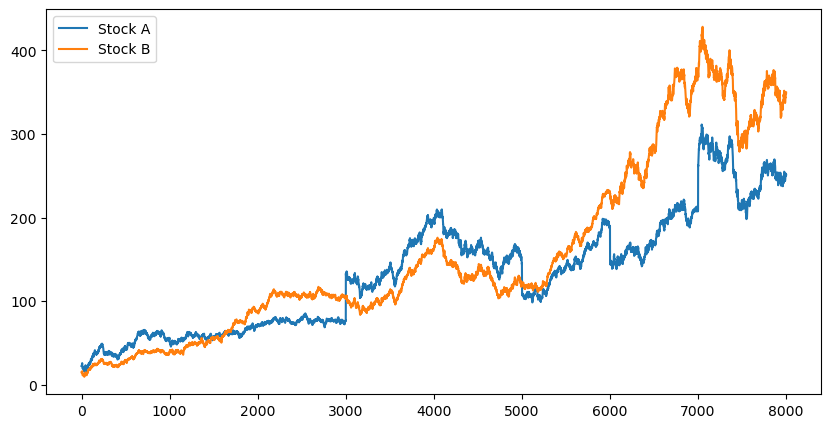

In [66]:
s1 = data_apple
s2 = data_microsoft

window_size = 400
points_per_window = 1000
s1_gen = [s1[0]]
s2_gen = [s2[0]]
et=s2[1]-s2[0]
epst=0
for i in range(len(s1)//window_size):
    params = estimate_all_params(s1[i*window_size:(i+1)*window_size], s2[i*window_size:(i+1)*window_size])
    for j in range(points_per_window):
        epst = params["c1"]+params["sigma1"]*np.random.normal()+params["phi1"]*epst
        et = params["c2"]+params["sigma2"]*np.random.normal()+params["phi2"]*et
        s2_gen.append(et+s2_gen[-1])
        s1_gen.append(epst-params["beta"]*s2_gen[-1]+params["intercept"])

for i in range(len(s1) // window_size):
    params = estimate_all_params(s1[i*window_size:(i+1)*window_size], s2[i*window_size:(i+1)*window_size])
    print(f"Window {i}: c1={params["c1"]} c2={params["c2"]} phi1={params['phi1']:.3f}, phi2={params['phi2']:.3f}, "
          f"sigma1={params['sigma1']:.4f}, sigma2={params['sigma2']:.4f}, "
          f"beta={params['beta']:.3f}")
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(s1_gen, label = "Stock A")
ax.plot(s2_gen, label = "Stock B")
# ax.set_yscale('log')
ax.legend()
plt.show()

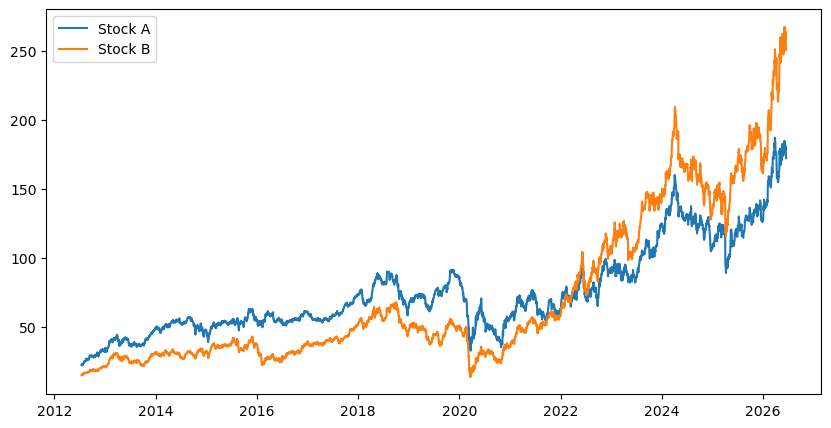

In [67]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(data_apple, label="Stock A")
ax.plot(data_microsoft, label="Stock B")
# ax.set_yscale('log')
ax.legend()

In [68]:
s1 = data_apple
s2 = data_microsoft

window_size = len(s1)-1
points_per_window = 1000000
s1_gen = [s1[0]]
s2_gen = [s2[0]]
et=s2[1]-s2[0]
epst=0
betas = []
for i in range(len(s1)-window_size):
    params = estimate_all_params(s1[i:i+window_size], s2[i:i+window_size])
    betas.append(params["beta"])
    for j in range(points_per_window):
        epst = params["c1"]/points_per_window+params["sigma1"]*np.random.normal()*np.sqrt(points_per_window)/points_per_window*100+params["phi1"]*epst
        et = params["c2"]/points_per_window+params["sigma2"]*np.random.normal()*np.sqrt(points_per_window)/points_per_window*100+params["phi2"]*et
        s2_gen.append(et+s2_gen[-1])
        s1_gen.append(epst-params["beta"]*s2_gen[-1]+params["intercept"])
# s1_gen = np.exp(s1_gen)
# s2_gen = np.exp(s2_gen)

C:\Users\lpset\AppData\Local\Temp\ipykernel_15420\3890653898.py:6: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  s1_gen = [s1[0]]
C:\Users\lpset\AppData\Local\Temp\ipykernel_15420\3890653898.py:7: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  s2_gen = [s2[0]]
C:\Users\lpset\AppData\Local\Temp\ipykernel_15420\3890653898.py:8: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  et=s2[1]-s2[0]


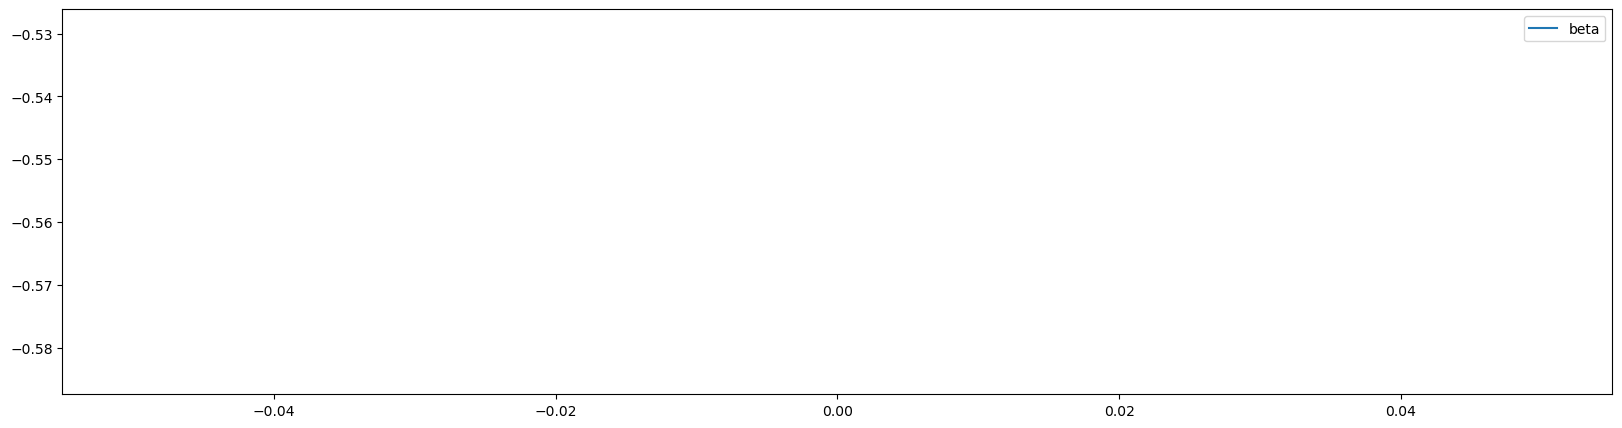

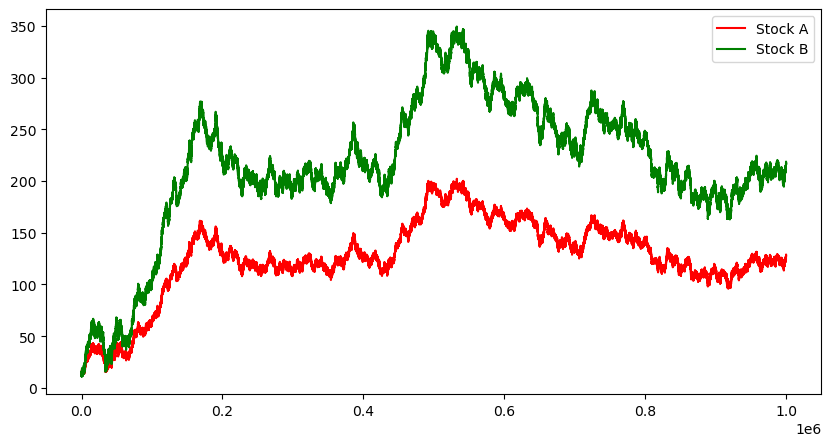

In [69]:
fig, ax = plt.subplots(figsize=(20, 5))
ax.plot(betas, label = "beta")
ax.legend()
plt.show()
s1_gen = np.array(s1_gen)
s2_gen = np.array(s2_gen)
s1_gen -= (s1_gen[2]-s2_gen[2])
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(s1_gen[1:], label="Stock A", color='red')
ax.plot(s2_gen[1:], label="Stock B", color='green')
# ax.set_yscale('log')
ax.legend()

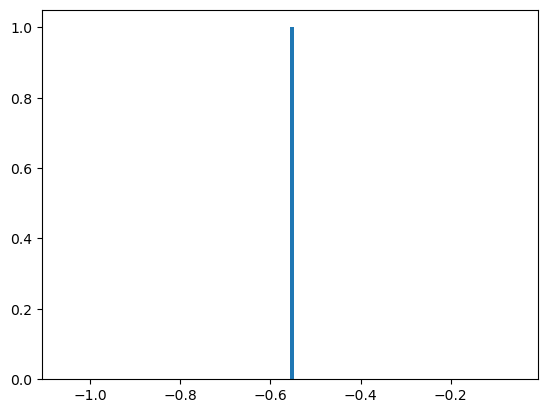

In [70]:
plt.hist(betas, bins=100)
plt.show()

In [71]:
import pandas as pd

# Sample Data
data = {"s1":s1_gen[1:], "s2":s2_gen[1:]}
df = pd.DataFrame(data)
# Output to CSV
df.to_csv('data_one_regime.csv', index=False)